In [1]:
import pypowsybl.network as pn
import pypowsybl.dynamic as dyn
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
from helpers import *

In [3]:
def baseMapping():
    model_mapping = dyn.ModelMapping()

    model_mapping.add_infinite_bus(
        static_id="VL1_BUS1", parameter_set_id="InfiniteBus", model_name="InfiniteBus"
    )

    model_mapping.add_base_bus(static_id="VL2_BUS1", parameter_set_id="bus1", model_name="Bus")
    model_mapping.add_base_bus(static_id="VL3_BUS1", parameter_set_id="bus2", model_name="Bus")

    model_mapping.add_base_line(static_id="line1", parameter_set_id="line1", model_name="Line")
    model_mapping.add_base_line(static_id="line2", parameter_set_id="line2", model_name="Line")

    model_mapping.add_base_transformer(
        static_id="TR", parameter_set_id="TR", model_name="TransformerFixedRatio"
    )

    return model_mapping

We want to use the influence of the modeling choice on the Generator

In [4]:
model_mapping1 = baseMapping()
model_mapping1.add_synchronous_generator(
    static_id="SM",
    parameter_set_id="SM",
    model_name="GeneratorSynchronousFourWindingsProportionalRegulations",
)

model_mapping2 = baseMapping()
model_mapping2.add_synchronous_generator(
    static_id="SM",
    parameter_set_id="SM_GoverPropVRPropInt",
    model_name="GeneratorSynchronousFourWindingsGoverPropVRPropInt",
)

In [5]:
event_mapping = dyn.EventMapping()
event_mapping.add_node_fault(static_id="VL2_BUS1", start_time=1, fault_time=0.07, r_pu=0, x_pu=0)

In [6]:
variables_mapping = dyn.OutputVariableMapping()
variables_mapping.add_dynamic_model_curves("SM", "generator_QGen")

In [7]:
iidm_filename = "smib.xiidm"
parfilePath = "/home/bureaugau/Projects/dynamo/dynawo-notebook/SMIB/SMIB.par"
updateParValue(parfilePath, "SM", "generator_H", "3.5")
updateParValue(parfilePath, "SM", "governor_KGover", "5")

In [8]:
network1 = pn.load(iidm_filename)
sim = dyn.Simulation()
res1 = sim.run(network1, model_mapping1, event_mapping, variables_mapping, 0, 30)
print(res1.status())

DynamicSimulationStatus.SUCCESS


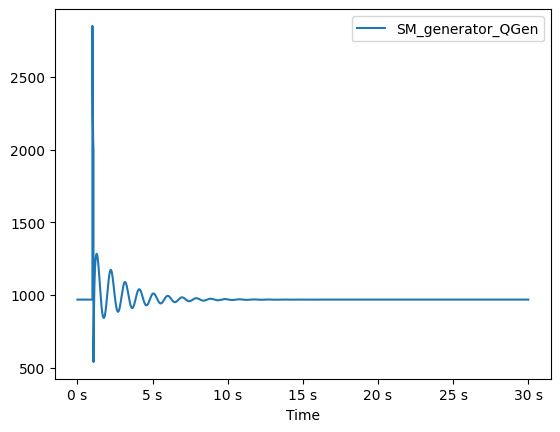

In [9]:
curves1 = res1.curves()
curveName = curves1.columns.tolist()[0]
plot(curves1)

In [10]:
network2 = pn.load(iidm_filename)
res2 = sim.run(network2, model_mapping2, event_mapping, variables_mapping, 0, 30)
print(res2.status())

DynamicSimulationStatus.SUCCESS


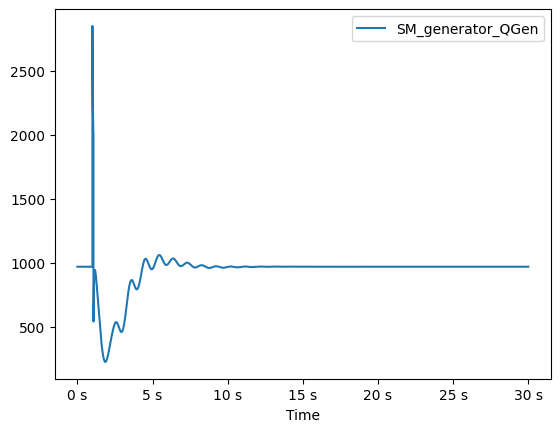

In [11]:
curves2 = res2.curves()
plot(curves2)

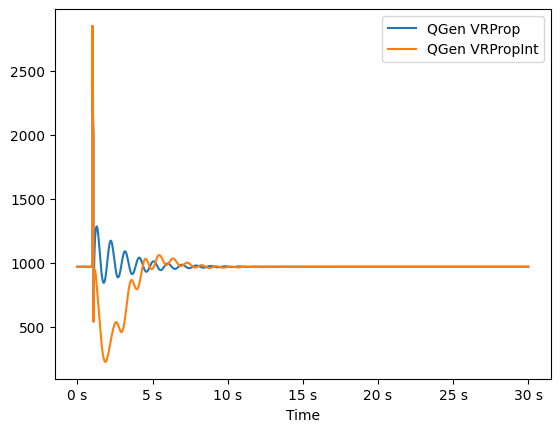

In [12]:
figure = addPlot(curves1, curveName, "QGen VRProp")
plotSameGraph(curves2, figure, curveName, "QGen VRPropInt")